In [1]:
import os
import sys

# Adds the parent directory to the python path
sys.path.append(os.path.abspath(os.path.join("..")))
import pandas as pd
import joblib

from src.explainability import (
    feature_importance,
    generate_shap,
    shap_summary,
    shap_bar,
    save_force_plot,
    get_prediction_examples
)

In [2]:
test_df = pd.read_csv(
    "../data/processed/fraud_test.csv"
)

X_test = test_df.drop(
    "class",
    axis=1
)

y_test = test_df["class"]
model = joblib.load(
    "../models/best_model.pkl"
)

/home/welela/Downloads/fraud-detection/src/explainability.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


,feature,importance
9,device_transaction_count,0.404568
5,time_since_signup,0.204689
2,ip_address,0.041835
1,age,0.040691
4,upper_bound_ip_address,0.038598
3,lower_bound_ip_address,0.038409
0,purchase_value,0.038220
6,hour_of_day,0.032113
7,day_of_week,0.024553
12,source_SEO,0.019077


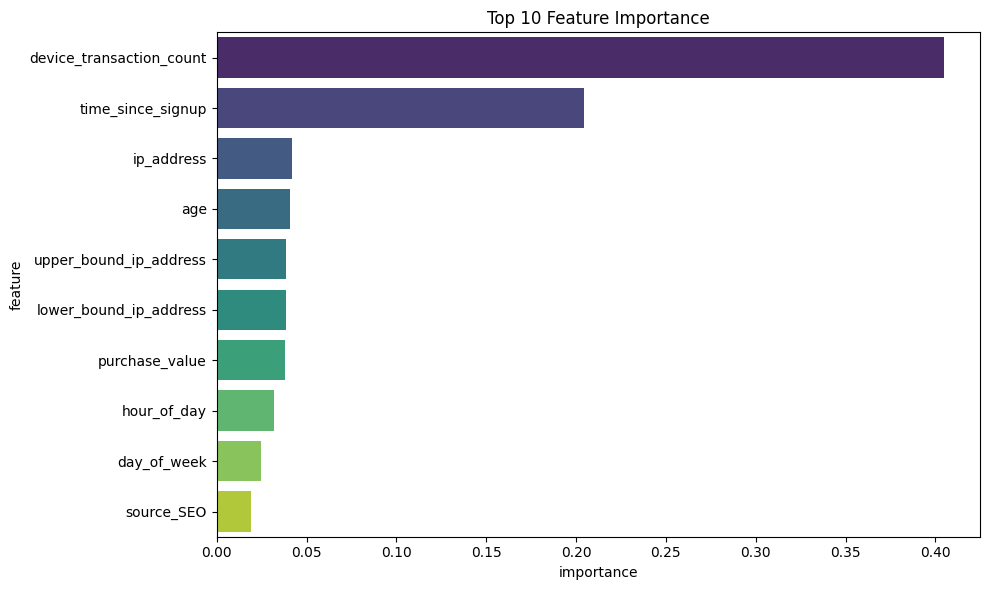

In [3]:
importance_df = feature_importance(
    model,
    X_test,
    "../models/top10_feature_importance.png"
)

importance_df.head(10)

In [ ]:
explainer, shap_values = generate_shap(
    model,
    X_test
)

In [ ]:
shap_summary(
    shap_values,
    X_test,
    "../models/shap_summary.png"
)

In [ ]:
shap_bar(
    shap_values,
    X_test,
    "../models/shap_bar.png"
)

In [ ]:
predictions = model.predict(X_test)

tp_idx, fp_idx, fn_idx = get_prediction_examples(
    X_test,
    y_test,
    predictions
)

In [ ]:
save_force_plot(
    explainer,
    shap_values,
    X_test,
    tp_idx,
    "../models/force_tp.html"
)

In [ ]:
save_force_plot(
    explainer,
    shap_values,
    X_test,
    fp_idx,
    "../models/force_fp.html"
)

In [ ]:
save_force_plot(
    explainer,
    shap_values,
    X_test,
    fn_idx,
    "../models/force_fn.html"
)

In [ ]:
shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "shap_importance": abs(shap_values).mean(axis=0)
})

comparison = importance_df.merge(
    shap_importance,
    on="feature"
)

comparison.sort_values(
    by="shap_importance",
    ascending=False
).head(10)

In [ ]:
top5_drivers = comparison.sort_values(
    by="shap_importance",
    ascending=False
).head(5)

print(top5_drivers[[
    "feature",
    "shap_importance"
]])